[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/22_1_pipelines_avances.ipynb)



# Pipelines avancés : données hétérogènes

Le notebook 22.0 montrait un pipeline en ligne droite : un scaler, puis un modèle.
Mais les vraies données sont hétérogènes des colonnes numériques (âge, prix)
et des colonnes catégorielles (sexe, port), chacune ayant besoin d'un traitement
différent.

On ne peut pas appliquer un `StandardScaler` à du texte, ni un `OneHotEncoder` à
un âge. Ce notebook montre comment router chaque colonne vers le bon traitement,
avec le `ColumnTransformer`.

## Le plan

| Section | Le sujet |
|---|---|
| 1 | Le problème : un pipeline simple échoue |
| 2 | ColumnTransformer : router les colonnes |
| 3 | Deux pipelines, un par type de colonne |
| 4 | make_column_selector : sélection automatique |
| 5 | make_union : des transformations en parallèle |
| 6 | Le pipeline complet et honnête |

## Trois pièges annoncés

Un pipeline simple plante sur des données mixtes NaN et texte.

`make_column_transformer` jette les colonnes non listées : elles disparaissent
silencieusement.

Et deux sélecteurs avec la même condition sélectionnent la même chose le
numérique doit `include`, le catégoriel `exclude`.

Prérequis : le notebook 22.0.

## 1. Le problème : un pipeline simple échoue

Chargeons le Titanic, riche en colonnes de types variés.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

titanic = sns.load_dataset('titanic')

# 'alive' est une copie déguisée de 'survived' : à retirer (fuite)
titanic = titanic.drop(columns=['alive'])

y = titanic['survived']
x = titanic.drop('survived', axis=1)

print(x.dtypes)

pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alone              bool
dtype: object


On retire `alive` d'emblée : c'est `survived` en texte (« yes »/« no »), donc une
fuite évidente le modèle tricherait. C'est le genre de colonne redondante à
repérer, comme au notebook 17.

Regarde les types : certaines colonnes sont numériques (`age`, `fare`), d'autres
textuelles (`sex`, `embarked`), d'autres booléennes ou catégorielles.

### Le pipeline simple plante

In [26]:
model = make_pipeline(StandardScaler(), SGDClassifier())

try:
    model.fit(x, y)
except ValueError as e:
    print('ValueError :', str(e)[:80])

ValueError : could not convert string to float: 'male'


Deux raisons à l'échec. `StandardScaler` ne sait pas traiter du texte comme
« male » ou « female ». Et les données contiennent des NaN que ni le scaler ni
le modèle n'acceptent.

Il faut donc traiter différemment les colonnes selon leur nature c'est le rôle
du `ColumnTransformer`.

## 2. ColumnTransformer : router les colonnes

`make_column_transformer` applique un transformer donné à des colonnes précises.

In [27]:
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer

# Version minimale : StandardScaler sur deux colonnes seulement
transformer = make_column_transformer(
    (make_pipeline(SimpleImputer(), StandardScaler()), ['age', 'fare']))

resultat = transformer.fit_transform(x)
print('forme entrée :', x.shape)
print('forme sortie :', resultat.shape)

forme entrée : (891, 13)
forme sortie : (891, 2)


### Le piège : les colonnes non listées disparaissent

La sortie n'a que 2 colonnes seules `age` et `fare` ont survécu. Toutes les
autres ont été jetées silencieusement.

C'est le comportement par défaut de `make_column_transformer` : il ne garde que
ce qu'on lui a explicitement donné. Le reste est supprimé sans avertissement.

Pour garder les colonnes non transformées, on ajoute `remainder='passthrough'` :

```python
make_column_transformer(
    (StandardScaler(), ['age', 'fare']),
    remainder='passthrough')
```

Mais attention : les colonnes passées telles quelles peuvent contenir du texte ou
des NaN qui feront replanter le modèle. Le plus propre est de traiter toutes
les colonnes explicitement c'est ce qu'on fait ensuite.

## 3. Deux pipelines, un par type

La bonne approche : un pipeline pour les colonnes numériques, un autre pour les
catégorielles, chacun avec son imputation adaptée.

In [28]:
from sklearn.preprocessing import OneHotEncoder

numerical_features = ['pclass', 'age', 'fare']
categorical_features = ['sex', 'embarked', 'who']

numerical_pipeline = make_pipeline(
    SimpleImputer(), # bouche par la moyenne
    StandardScaler())

categorical_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'), # bouche par la catégorie majoritaire
    OneHotEncoder(handle_unknown='ignore'))

Deux stratégies d'imputation différentes, et c'est le point clé.

Pour le numérique, `SimpleImputer()` bouche les trous avec la moyenne de la
colonne le défaut.

Pour le catégoriel, on ne peut pas faire la moyenne de « male » et « female ».
On bouche donc avec la catégorie la plus fréquente, via
`strategy='most_frequent'`.

Chaque type de donnée exige son traitement. C'est toute la raison d'être de cette
séparation.

### Assembler avec le ColumnTransformer

In [29]:
preprocessor = make_column_transformer(
    (numerical_pipeline, numerical_features),
    (categorical_pipeline, categorical_features))

model = make_pipeline(preprocessor, SGDClassifier(random_state=0))
model.fit(x, y)

print('score :', round(model.score(x, y), 3))

score : 0.795


Ça fonctionne. Le `ColumnTransformer` a envoyé `pclass`, `age`, `fare` au pipeline
numérique, et `sex`, `embarked`, `who` au pipeline catégoriel. Chaque colonne a
reçu l'imputation et la transformation qui lui convient.

Le piège de l'objet trompé. Une erreur fréquente est de réutiliser un
`transformer` incomplet (qui ne traite que deux colonnes, sans imputation) au lieu
du `preprocessor` complet. Le premier laisse passer des NaN et le modèle plante.
Toujours vérifier qu'on passe le bon objet.

### handle_unknown='ignore'

Cet argument du `OneHotEncoder` évite un plantage si une catégorie apparaît au
test mais pas à l'entraînement. Sans lui, l'encodeur lève une erreur le
défaut vu au notebook 22.0. Avec, la catégorie inconnue devient une ligne de zéros.

## 4. make_column_selector : sélection automatique

Lister les colonnes à la main est fastidieux et fragile. `make_column_selector`
les choisit automatiquement selon leur type.

In [30]:
from sklearn.compose import make_column_selector

numerical_features = make_column_selector(dtype_include=np.number)
categorical_features = make_column_selector(dtype_include=object)

print('numériques :', numerical_features(x))
print('catégorielles :', categorical_features(x))

numériques : ['pclass', 'age', 'sibsp', 'parch', 'fare']
catégorielles : ['sex', 'embarked', 'who', 'embark_town']


### Le piège des deux mêmes conditions

L'erreur classique : mettre `dtype_exclude=np.number` des deux côtés. Les deux
sélecteurs choisiraient alors la même chose les colonnes non numériques et le
pipeline numérique recevrait du texte, ce qui plante.

La bonne combinaison : le numérique inclut les nombres, le catégoriel
sélectionne les colonnes texte.

```python
numerical_features = make_column_selector(dtype_include=np.number) # les nombres
categorical_features = make_column_selector(dtype_include=object) # le texte
```

### Pourquoi include=object plutôt que exclude=np.number

Sur le Titanic, `dtype_exclude=np.number` attraperait aussi les colonnes booléennes et catégorielles (`adult_male`, `class`, `deck`), sur
lesquelles `SimpleImputer(strategy='most_frequent')` peut buter selon la version
de sklearn.

Cibler explicitement `dtype_include=object` le texte pur est plus sûr. C'est
un bon rappel : le sélecteur automatique choisit par type technique, sans
connaître le sens des colonnes. Il faut toujours vérifier ce qu'il attrape.

In [31]:
numerical_pipeline = make_pipeline(SimpleImputer(), StandardScaler())
categorical_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore'))

preprocessor = make_column_transformer(
    (numerical_pipeline, make_column_selector(dtype_include=np.number)),
    (categorical_pipeline, make_column_selector(dtype_include=object)))

model = make_pipeline(preprocessor, SGDClassifier(random_state=0))
model.fit(x, y)

print('score :', round(model.score(x, y), 3))

score : 0.708


L'avantage du sélecteur automatique : si on ajoute une colonne aux données, elle
sera automatiquement dirigée vers le bon pipeline selon son type, sans toucher
au code. Plus robuste qu'une liste figée.

## 5. make_union : des transformations en parallèle

`make_pipeline` enchaîne les étapes en série. `make_union` les applique en
parallèle sur les mêmes données, puis colle les résultats.

In [32]:
from sklearn.pipeline import make_union
from sklearn.preprocessing import Binarizer

# De vraies données numériques, imputées
X_num = SimpleImputer().fit_transform(x[['pclass', 'age', 'fare']])

pipeline = make_union(
    StandardScaler(),
    Binarizer(threshold=3))

resultat = pipeline.fit_transform(X_num)

print('forme entrée :', X_num.shape)
print('forme sortie :', resultat.shape)

forme entrée : (891, 3)
forme sortie : (891, 6)


Trois colonnes en entrée deviennent six en sortie : la version standardisée (3
colonnes) collée à la version binarisée (3 colonnes).

`make_union` a appliqué les deux transformations en parallèle, chacune sur le
`X` d'origine, puis a concaténé.

### La différence série / parallèle

```
make_pipeline :   X → Scaler → Binarizer → sortie          (série)

make_union :      X → Scaler ─┐
                  X → Binarizer ─┴→ [colonnes collées]      (parallèle)
```

En série, la sortie du scaler devient l'entrée du binarizer. En parallèle, les
deux voient le même `X` et leurs sorties sont juxtaposées.

À quoi ça sert. Donner au modèle plusieurs représentations de la même
variable la valeur normalisée et un seuil. Le modèle dispose alors de deux
angles sur la même donnée.

Deux pièges dans cette cellule. `X_num` doit être de vraies données, pas un
`make_column_selector` (qui ne fait que sélectionner). Et l'imputation est
nécessaire, car `Binarizer` n'accepte pas les NaN d'où le `SimpleImputer` en
amont.

`make_union` est moins courant que `ColumnTransformer`, mais utile pour enrichir
des variables avec plusieurs transformations simultanées.

## 6. Le pipeline complet et honnête

Rassemblons tout : sélection automatique, imputation adaptée, encodage, modèle et une validation croisée honnête.

In [33]:
from sklearn.model_selection import cross_val_score

numerical_pipeline = make_pipeline(SimpleImputer(), StandardScaler())
categorical_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore'))

preprocessor = make_column_transformer(
    (numerical_pipeline, make_column_selector(dtype_include=np.number)),
    (categorical_pipeline, make_column_selector(dtype_include=object)))

model = make_pipeline(preprocessor, SGDClassifier(random_state=0))

scores = cross_val_score(model, x, y, cv=5)
print('scores :', scores.round(3))
print('moyenne:', scores.mean().round(4))

scores : [0.654 0.803 0.792 0.826 0.747]
moyenne: 0.7644


Pourquoi ce pipeline est honnête. Toute la chaîne imputation, mise à
l'échelle, encodage est dans le pipeline. En validation croisée, chaque
étape est réajustée sur les plis d'entraînement uniquement, jamais sur le pli de
validation.

Si on avait imputé ou normalisé avant la validation croisée, on aurait laissé
fuiter l'information du test la faute des notebooks 21 et 22.0. Ici, c'est
structurellement impossible.

C'est l'aboutissement de tout le bloc prétraitement : une chaîne complète, qui
gère des données réelles et hétérogènes, sans aucune fuite. Ce `model` peut passer
directement dans un `GridSearchCV` pour régler ses hyperparamètres, toujours sans
fuite.

### Voir la structure du pipeline

In [34]:
model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fda1478f7a0>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fda11be6210>)])),
                ('sgdclassifier', SGDClassifier(random_state=0))])

Afficher le modèle montre son arborescence : le `ColumnTransformer` avec ses deux
branches, chacune avec son imputeur et son transformer, puis le classifieur final.
C'est un estimateur composite un objet unique qui contient toute la logique
de préparation et de modélisation.

## 7. Mémo

### Les outils

| Outil | Rôle |
|---|---|
| `make_column_transformer` | route des colonnes vers des transformers |
| `make_column_selector` | sélectionne les colonnes par type |
| `make_union` | applique des transformers en parallèle |
| `SimpleImputer` | bouche les valeurs manquantes |

### La structure type

```python
num_pipe = make_pipeline(SimpleImputer(), StandardScaler())
cat_pipe = make_pipeline(SimpleImputer(strategy='most_frequent'),
                         OneHotEncoder(handle_unknown='ignore'))

preprocessor = make_column_transformer(
    (num_pipe, make_column_selector(dtype_include=np.number)),
    (cat_pipe, make_column_selector(dtype_include=object)))

model = make_pipeline(preprocessor, SGDClassifier())
```

### Imputation selon le type

| Type | Stratégie |
|---|---|
| Numérique | `SimpleImputer()` moyenne |
| Catégoriel | `SimpleImputer(strategy='most_frequent')` mode |

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| Pipeline simple sur données mixtes | plante sur texte et NaN |
| Colonnes non listées | jetées silencieusement |
| Deux sélecteurs identiques | même sélection, pipeline faux |
| `exclude=np.number` | attrape aussi bool et category |
| `make_union` sur un sélecteur | erreur, il faut des données |
| Imputer avant la validation croisée | fuite d'information |
| Oublier `handle_unknown='ignore'` | plante sur catégorie inconnue |

## 8. Exercices

**Exercice 1**

Sur le Titanic complet, compare deux stratégies via validation croisée : imputer
l'âge par la moyenne, puis par la médiane. L'écart est-il grand ? Relie ta
réponse à la distribution de l'âge et à la leçon du notebook 08.

**Exercice 2**

Construis le pipeline complet, puis mets-le dans un `GridSearchCV` qui teste deux
stratégies d'imputation numérique (`'mean'` et `'median'`) et deux pénalités du
`SGDClassifier`. Utilise la syntaxe à double underscore pour atteindre un
paramètre profond dans le pipeline. Quel est le meilleur réglage ?

**Exercice 3**

Ce code prétend préparer les données avant la validation croisée :

```python
imputer = SimpleImputer()
x_num = imputer.fit_transform(x[['age', 'fare']]) # sur tout x
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_num) # sur tout x
scores = cross_val_score(SGDClassifier(), x_scaled, y, cv=5)
```

Il contient deux fuites d'information. Identifie-les, explique pourquoi
chacune fausse la validation, puis corrige en mettant tout dans un pipeline.

## Pour continuer

Tu maîtrises maintenant la préparation de données réelles, hétérogènes et
trouées la partie la moins spectaculaire mais la plus décisive du machine
learning. Un modèle passe rarement sur des données brutes.

Les notebooks suivants exploreront la sélection de variables, les modèles
d'ensemble et l'apprentissage non supervisé. Le pipeline restera ton ossature :
quelle que soit leur complexité, les étapes s'y enchaînent sans jamais laisser
fuiter le test.

In [35]:
# Exercice 1

In [36]:
import numpy as np
import seaborn as sns
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score

titanic = sns.load_dataset('titanic').drop(columns=['alive'])
y = titanic['survived']
x = titanic.drop('survived', axis=1)

def construire(strategie):
    num = make_pipeline(SimpleImputer(strategy=strategie), StandardScaler())
    cat = make_pipeline(SimpleImputer(strategy='most_frequent'),
                        OneHotEncoder(handle_unknown='ignore'))
    pre = make_column_transformer(
        (num, make_column_selector(dtype_include=np.number)),
        (cat, make_column_selector(dtype_include=object)))
    return make_pipeline(pre, SGDClassifier(random_state=0))

for strategie in ['mean', 'median']:
    score = cross_val_score(construire(strategie), x, y, cv=5).mean()
    print(f'imputation par {strategie:<8} : {score:.4f}')

imputation par mean     : 0.7644
imputation par median   : 0.7980


moyenne : 29.7
médiane : 28.0


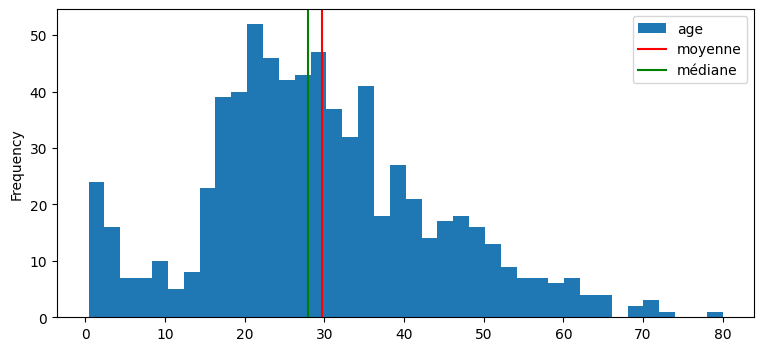

In [37]:
print('moyenne :', round(titanic['age'].mean(), 1))
print('médiane :', round(titanic['age'].median(), 1))

titanic['age'].plot(kind='hist', bins=40, figsize=(9, 4))
import matplotlib.pyplot as plt
plt.axvline(titanic['age'].mean(), color='red', label='moyenne')
plt.axvline(titanic['age'].median(), color='green', label='médiane')
plt.legend()
plt.show()

In [38]:
# Exercice 2

In [39]:
from sklearn.model_selection import GridSearchCV

# Le pipeline complet
num = make_pipeline(SimpleImputer(), StandardScaler())
cat = make_pipeline(SimpleImputer(strategy='most_frequent'),
                    OneHotEncoder(handle_unknown='ignore'))
preprocessor = make_column_transformer(
    (num, make_column_selector(dtype_include=np.number)),
    (cat, make_column_selector(dtype_include=object)))
model = make_pipeline(preprocessor, SGDClassifier(random_state=0))

In [40]:
# Voir les noms de paramètres disponibles
imputer_params = [k for k in model.get_params() if 'imputer' in k and 'strategy' in k]
print(imputer_params)

['columntransformer__pipeline-1__simpleimputer__strategy', 'columntransformer__pipeline-2__simpleimputer__strategy']


In [41]:
params = {
    'columntransformer__pipeline-1__simpleimputer__strategy': ['mean', 'median'],
    'sgdclassifier__penalty': ['l1', 'l2'],
}

grid = GridSearchCV(model, params, cv=5)
grid.fit(x, y)

print('meilleur réglage :', grid.best_params_)
print('meilleur score   :', round(grid.best_score_, 4))

meilleur réglage : {'columntransformer__pipeline-1__simpleimputer__strategy': 'median', 'sgdclassifier__penalty': 'l2'}
meilleur score   : 0.798


In [42]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num, make_column_selector(dtype_include=np.number)),
    ('cat', cat, make_column_selector(dtype_include=object)),
])
# le paramètre devient : 'columntransformer__num__simpleimputer__strategy'

In [43]:
# Exercice 3

In [44]:
imputer = SimpleImputer()
x_num = imputer.fit_transform(x[['age', 'fare']]) # sur tout x
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_num) # sur tout x
scores = cross_val_score(SGDClassifier(), x_scaled, y, cv=5)

In [45]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score

pipeline = make_pipeline(
    SimpleImputer(),
    StandardScaler(),
    SGDClassifier(random_state=0))

scores = cross_val_score(pipeline, x[['age', 'fare']], y, cv=5)

print('scores :', scores.round(3))
print('moyenne:', scores.mean().round(4))

scores : [0.603 0.708 0.674 0.596 0.68 ]
moyenne: 0.6521


In [46]:
# Version fautive
imp = SimpleImputer(); xn = imp.fit_transform(x[['age', 'fare']])
sc = StandardScaler(); xs = sc.fit_transform(xn)
fautif = cross_val_score(SGDClassifier(random_state=0), xs, y, cv=5).mean()

# Version propre
propre = cross_val_score(pipeline, x[['age', 'fare']], y, cv=5).mean()

print(f'avec fuites : {fautif:.4f}')
print(f'sans fuite  : {propre:.4f}')

avec fuites : 0.6521
sans fuite  : 0.6521
